# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студентки гр. 2384 Лавренова Юлия и Соц Екатерина. Вариант №32

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

**Ранжированный ряд** — упорядоченный по возрастанию или убыванию набор значений выборочного признака.

**Вариационный ряд** — совокупность уникальных значений признака с указанием их частоты встречаемости.

**Интервальный ряд** строится путём разбиения диапазона значений признака на несколько непересекающихся интервалов (частичных интервалов). Для каждого интервала вычисляются:
 - середина интервала $\tilde{x}_i$
 - абсолютная частота $m_i$ — число значений, попавших в интервал
 - относительная частота $\tilde{m}_i = \frac{m_i}{N}$, где $N$ — объём выборки
 - накопленная абсолютная частота $m_{\mathrm{нак}\,i} = \sum_{j=1}^{i} m_j$
 - накопленная относительная частота $\tilde{m}_{\mathrm{нак}\,i} = \sum_{j=1}^{i} \tilde{m}_j$

Для анализа распределения признака по выборке строятся графики:

- **Гистограмма** — столбчатая диаграмма, отображающая абсолютные или относительные частоты интервалов
- **Полигон частот** — ломаная линия, соединяющая точки, соответствующие серединам интервалов и их частотам
- **Эмпирическая функция распределения** — ступенчатая функция, которая показывает накопленную относительную частоту до каждого значения признака

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы


### 1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.

Для выполнения практических работ выбран язык программирования Python. Python обладает понятным и логичным синтаксисом, что позволяет быстро реализовать алгоритмы формирования выборки, её сортировки и последующего анализа. Также данный язык программирования обладает большим количеством специализированных библиотек для работы с экспериментальными данными. Python предоставляет простые средства для наглядного графического представления результатов, в частности для построения гистограмм, функций распределения и других графиков. Это облегчает визуальный анализ данных и позволяет сделать содержательные выводы по полученным результатам.

### 2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку

Генеральная совокупность взята из [этого сайта](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset/), предварительно она согласована с преподавателем.

### 3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.

Из генеральной совокупности сформирована простая случайная выборка объемом 114 наблюдений. Для обеспечения воспроизводимости результатов использован параметр random_state=42. Из всего набора признаков были отобраны две переменные: pH и sulphates.

In [ ]:
import pandas as pd
df = pd.read_csv('WineQT.csv')
sample = df.sample(n=114, random_state=42)[['pH', 'sulphates']]
sample.to_csv('sample_wine_data.csv', index=False)
sample.head()

,pH,sulphates
158,3.42,0.60
1081,3.53,0.72
291,3.44,0.48
538,3.09,1.06
367,3.25,0.74


### 4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.

In [3]:
import pandas as pd

data = pd.read_csv("sample_wine_data.csv")
data.head()

,pH,sulphates
0,3.42,0.60
1,3.53,0.72
2,3.44,0.48
3,3.09,1.06
4,3.25,0.74


In [7]:
#разбиение для признака pH

import numpy as np

def group_array(data):
  # ранжированный
  df_range = np.sort(data)

  # вариационный
  df_unique = np.unique(df_range)
  df_var = {value: np.sum(df_range == value) for value in df_unique}

  # интервальный

  N = 114
  k = round(1 + 3.322*np.log10(N))
  h = (max(df_unique) - min(df_unique)) / k
  bins = np.linspace(min(df_unique), max(df_unique), k)
  m_i, edges = np.histogram(data, bins=bins)

  x_i_mid = (edges[:-1] + edges[1:]) / 2
  m_i_rel = m_i / N
  m_i_cum = np.cumsum(m_i)
  m_i_rel_cum = np.cumsum(m_i_rel)
  interval_series = pd.DataFrame({
      "Интервал": [f"{round(edges[i],2)} – {round(edges[i+1],2)}" for i in range(len(m_i))],
      "Абсолютная частота": m_i,
      "Относительная частота": m_i / N
  })
  table = pd.DataFrame({
      "i": range(1, len(m_i)+1),
      "$[x_i, x_{i+1})$": [f"[{edges[i]:.2f}, {edges[i+1]:.2f})" for i in range(len(m_i))],
      "$\\tilde{x}_i$": np.round(x_i_mid, 3),
      "$m_i$": m_i,
      "$\\tilde{m}_i$": np.round(m_i_rel, 4),
      "$m_{i}^{нак}$": m_i_cum,
      "$\\tilde{m}_{i}^{нак}$": np.round(m_i_rel_cum, 4)
  })


  sum_row = pd.DataFrame({
      "i": ["Σ"],
      "$[x_i, x_{i+1})$": ["-"],
      "$\\tilde{x}_i$": ["-"],
      "$m_i$": [m_i.sum()],
      "$\\tilde{m}_i$": [m_i_rel.sum()],
      "$m_{i}^{нак}$": ["-"],
      "$\\tilde{m}_{i}^{нак}$": ["-"]
  })

  table = pd.concat([table, sum_row], ignore_index=True)

  return df_range, df_var, interval_series, table


print("Признак pH:")
data_ph = np.array(data["pH"])
ph_range, ph_var, ph_interval, ph_table = group_array(data_ph)
print("Ранжированный ряд:")
print(ph_range)
print("Вариационный ряд:")
print(ph_var)
print("Интервальный ряд:")
print(ph_interval)

print("Признак sulphates:")
data_sulphates = np.array(data["sulphates"])
sulphates_range, sulphates_var, sulphates_interval, sulphates_table = group_array(data_sulphates)
print("Ранжированный ряд:")
print(sulphates_range)
print("Вариационный ряд:")
print(sulphates_var)
print("Интервальный ряд:")
print(sulphates_interval)

Признак pH:
Ранжированный ряд:
[2.86 2.88 2.89 2.9  2.94 3.02 3.04 3.07 3.08 3.09 3.09 3.1  3.11 3.12
 3.12 3.13 3.15 3.16 3.16 3.17 3.17 3.17 3.17 3.18 3.18 3.19 3.2  3.2
 3.2  3.2  3.21 3.21 3.22 3.22 3.23 3.23 3.24 3.24 3.24 3.25 3.25 3.25
 3.25 3.25 3.26 3.27 3.27 3.27 3.28 3.28 3.28 3.29 3.29 3.3  3.3  3.31
 3.31 3.31 3.32 3.32 3.33 3.33 3.34 3.34 3.34 3.34 3.35 3.35 3.35 3.35
 3.35 3.35 3.36 3.36 3.36 3.36 3.36 3.38 3.38 3.38 3.38 3.39 3.39 3.39
 3.39 3.4  3.42 3.42 3.42 3.43 3.43 3.44 3.44 3.44 3.45 3.45 3.46 3.47
 3.47 3.48 3.49 3.5  3.5  3.52 3.53 3.54 3.54 3.58 3.59 3.68 3.7  3.72
 3.78 3.9 ]
Вариационный ряд:
{np.float64(2.86): np.int64(1), np.float64(2.88): np.int64(1), np.float64(2.89): np.int64(1), np.float64(2.9): np.int64(1), np.float64(2.94): np.int64(1), np.float64(3.02): np.int64(1), np.float64(3.04): np.int64(1), np.float64(3.07): np.int64(1), np.float64(3.08): np.int64(1), np.float64(3.09): np.int64(2), np.float64(3.1): np.int64(1), np.float64(3.11): np.int64(1), n

In [8]:
from IPython.display import display, Markdown

display(Markdown(ph_table.to_markdown(index=False)))

| i   | $[x_i, x_{i+1})$   | $\tilde{x}_i$   |   $m_i$ |   $\tilde{m}_i$ | $m_{i}^{нак}$   | $\tilde{m}_{i}^{нак}$   |
|:----|:-------------------|:----------------|--------:|----------------:|:----------------|:------------------------|
| 1   | [2.86, 3.01)       | 2.934           |       5 |          0.0439 | 5               | 0.0439                  |
| 2   | [3.01, 3.16)       | 3.083           |      12 |          0.1053 | 17              | 0.1491                  |
| 3   | [3.16, 3.31)       | 3.231           |      38 |          0.3333 | 55              | 0.4825                  |
| 4   | [3.31, 3.45)       | 3.38            |      41 |          0.3596 | 96              | 0.8421                  |
| 5   | [3.45, 3.60)       | 3.529           |      13 |          0.114  | 109             | 0.9561                  |
| 6   | [3.60, 3.75)       | 3.677           |       3 |          0.0263 | 112             | 0.9825                  |
| 7   | [3.75, 3.90)       | 3.826           |       2 |          0.0175 | 114             | 1.0                     |
| Σ   | -                  | -               |     114 |          1      | -               | -                       |

In [9]:
from IPython.display import display, Markdown

display(Markdown(sulphates_table.to_markdown(index=False)))

| i   | $[x_i, x_{i+1})$   | $\tilde{x}_i$   |   $m_i$ |   $\tilde{m}_i$ | $m_{i}^{нак}$   | $\tilde{m}_{i}^{нак}$   |
|:----|:-------------------|:----------------|--------:|----------------:|:----------------|:------------------------|
| 1   | [0.44, 0.61)       | 0.524           |      53 |          0.4649 | 53              | 0.4649                  |
| 2   | [0.61, 0.78)       | 0.693           |      42 |          0.3684 | 95              | 0.8333                  |
| 3   | [0.78, 0.95)       | 0.861           |      13 |          0.114  | 108             | 0.9474                  |
| 4   | [0.95, 1.11)       | 1.03            |       1 |          0.0088 | 109             | 0.9561                  |
| 5   | [1.11, 1.28)       | 1.199           |       2 |          0.0175 | 111             | 0.9737                  |
| 6   | [1.28, 1.45)       | 1.367           |       2 |          0.0175 | 113             | 0.9912                  |
| 7   | [1.45, 1.62)       | 1.536           |       1 |          0.0088 | 114             | 1.0                     |
| Σ   | -                  | -               |     114 |          1      | -               | -                       |

In [10]:
print("ПРИЗНАК pH")

# Основные статистики
ph_min = ph_range.min()
ph_max = ph_range.max()
ph_mean = np.mean(data_ph)
ph_median = np.median(data_ph)

print(f"1. Общая характеристика:")
print(f"   - Значения pH в выборке варьируются от {ph_min:.2f} до {ph_max:.2f}")
print(f"   - Среднее значение pH = {ph_mean:.3f}")
print(f"   - Медианное значение pH = {ph_median:.3f}")
print(f"   - Размах вариации: {ph_max - ph_min:.3f}")

# Анализ интервального ряда
max_freq_idx = ph_table['$m_i$'].iloc[:-1].idxmax()  # исключаем строку с суммой
max_interval = ph_table.loc[max_freq_idx, '$[x_i, x_{i+1})$']
max_freq = ph_table.loc[max_freq_idx, '$m_i$']
max_freq_rel = ph_table.loc[max_freq_idx, '$\\tilde{m}_i$'] * 100

print(f"\n2. Анализ распределения:")
print(f"   - Наиболее типичными являются значения в интервале {max_interval}")
print(f"   - В этот интервал попадает {max_freq} наблюдений ({max_freq_rel:.1f}% выборки)")

# Характер распределения
if ph_mean < ph_median:
    skew = "левостороннюю (отрицательную) асимметрию"
elif ph_mean > ph_median:
    skew = "правостороннюю (положительную) асимметрию"
else:
    skew = "симметричное распределение"

print(f"   - Распределение имеет {skew}")

print("\n3. Содержательный вывод для pH:")
if ph_min < 3.0:
    print("   - В выборке присутствуют образцы с очень низким pH (кислая среда).")
if ph_max > 3.8:
    print("   - Есть образцы с относительно высоким pH (менее кислая среда).")

# Сравнение с нормативными значениями (для вина)
print("   - Для вин типичными считаются значения pH в диапазоне 3.0-3.4.")
if ph_mean < 3.2:
    print("   - В среднем вина в выборке имеют повышенную кислотность.")
elif ph_mean > 3.5:
    print("   - В среднем вина в выборке имеют пониженную кислотность.")
else:
    print("   - Средний pH соответствует типичным значениям для вин.")

print("ПРИЗНАК SULPHATES")

# Основные статистики
s_min = sulphates_range.min()
s_max = sulphates_range.max()
s_mean = np.mean(data_sulphates)
s_median = np.median(data_sulphates)

print(f"1. Общая характеристика:")
print(f"   - Содержание сульфатов варьируется от {s_min:.2f} до {s_max:.2f}")
print(f"   - Среднее значение = {s_mean:.3f}")
print(f"   - Медианное значение = {s_median:.3f}")
print(f"   - Размах вариации: {s_max - s_min:.3f}")

# Анализ интервального ряда
max_freq_idx = sulphates_table['$m_i$'].iloc[:-1].idxmax()
max_interval = sulphates_table.loc[max_freq_idx, '$[x_i, x_{i+1})$']
max_freq = sulphates_table.loc[max_freq_idx, '$m_i$']
max_freq_rel = sulphates_table.loc[max_freq_idx, '$\\tilde{m}_i$'] * 100

print(f"\n2. Анализ распределения:")
print(f"   - Наиболее часто встречаются значения в интервале {max_interval}")
print(f"   - В этот интервал попадает {max_freq} образцов ({max_freq_rel:.1f}% выборки)")

# Оценка вариации
coef_variation = (np.std(data_sulphates) / s_mean) * 100
print(f"   - Коэффициент вариации: {coef_variation:.1f}%")

if coef_variation < 33:
    print("     Совокупность однородна по содержанию сульфатов.")
else:
    print("     Совокупность неоднородна по содержанию сульфатов.")

print("\n3. Содержательный вывод для sulphates:")
print("   - Сульфаты влияют на органолептические свойства вина и процесс ферментации.")
if s_mean > 0.6:
    print("   - В среднем содержание сульфатов повышенное, что может указывать")
    print("     на использование диоксида серы как консерванта.")
else:
    print("   - Содержание сульфатов находится в типичных пределах.")


ПРИЗНАК pH
1. Общая характеристика:
   - Значения pH в выборке варьируются от 2.86 до 3.90
   - Среднее значение pH = 3.308
   - Медианное значение pH = 3.310
   - Размах вариации: 1.040

2. Анализ распределения:
   - Наиболее типичными являются значения в интервале [3.31, 3.45)
   - В этот интервал попадает 41 наблюдений (36.0% выборки)
   - Распределение имеет левостороннюю (отрицательную) асимметрию

3. Содержательный вывод для pH:
   - В выборке присутствуют образцы с очень низким pH (кислая среда).
   - Есть образцы с относительно высоким pH (менее кислая среда).
   - Для вин типичными считаются значения pH в диапазоне 3.0-3.4.
   - Средний pH соответствует типичным значениям для вин.
ПРИЗНАК SULPHATES
1. Общая характеристика:
   - Содержание сульфатов варьируется от 0.44 до 1.62
   - Среднее значение = 0.660
   - Медианное значение = 0.620
   - Размах вариации: 1.180

2. Анализ распределения:
   - Наиболее часто встречаются значения в интервале [0.44, 0.61)
   - В этот интервал п

Построение ранжированного ряда позволило выявить минимальные и максимальные значения признаков, а также характер их распределения. Вариационный ряд показал частоту встречаемости конкретных значений, что важно для выявления модальных значений признаков. Интервальный ряд сгруппировал данные, что позволило сгладить случайные колебания частот и выявить основные закономерности распределения.


### 5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы
### 6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_analysis(table, N, title):
    x_mid = table["$\\tilde{x}_i$"][:-1].astype(float)
    abs_freq = table["$m_i$"][:-1]
    rel_freq = table["$\\tilde{m}_i$"][:-1]
    abs_cum = table["$m_{i}^{нак}$"][:-1].astype(int)
    rel_cum = table["$\\tilde{m}_{i}^{нак}$"][:-1].astype(float)

    edges = []
    for interval in table["$[x_i, x_{i+1})$"][:-1]:
        left = float(interval.split(",")[0][1:])
        right = float(interval.split(",")[1][:-1])
        edges.append((left, right))

    edges_left = [e[0] for e in edges]
    edges_right = [e[1] for e in edges]

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Анализ распределения признака: {title}\nОбъем выборки: {N}", fontsize=16)

    # 1. Полигон (абсолютные частоты)
    axs[0,0].plot(x_mid, abs_freq, marker='o', color='blue')
    axs[0,0].fill_between(x_mid, abs_freq, color='pink', alpha=0.4)
    axs[0,0].set_title("Полигон (абсолютные частоты)")
    axs[0,0].set_xlabel(f"{title}")
    axs[0,0].set_ylabel("Абсолютная частота")
    axs[0,0].grid(True)

    # 2. Гистограмма (абсолютные частоты)
    axs[0,1].bar(x_mid, abs_freq, width=edges_right[0]-edges_left[0], color='green', edgecolor='black', align='center')
    axs[0,1].set_title("Гистограмма (абсолютные частоты)")
    axs[0,1].set_xlabel(f"{title}")
    axs[0,1].set_ylabel("Абсолютная частота")
    axs[0,1].grid(True)

    # 3. Эмпирическая функция распределения
    x_step = np.array(edges_left + [edges_right[-1]])
    y_step = np.array([0] + list(abs_cum))
    axs[0,2].step(x_step, y_step / N, where='post', color='red', marker='o')
    axs[0,2].set_title("Эмпирическая функция распределения")
    axs[0,2].set_xlabel(f"{title}")
    axs[0,2].set_ylabel("F(x)")
    axs[0,2].grid(True)

    # 4. Полигон (относительные частоты)
    axs[1,0].plot(x_mid, rel_freq, marker='o', color='purple')
    axs[1,0].fill_between(x_mid, rel_freq, color='pink', alpha=0.4)
    axs[1,0].set_title("Полигон (относительные частоты)")
    axs[1,0].set_xlabel(f"{title}")
    axs[1,0].set_ylabel("Относительная частота")
    axs[1,0].grid(True)

    # 5. Гистограмма (относительные частоты)
    axs[1,1].bar(x_mid, rel_freq, width=edges_right[0]-edges_left[0], color='orange', edgecolor='black', align='center')
    axs[1,1].set_title("Гистограмма (относительные частоты)")
    axs[1,1].set_xlabel(f"{title}")
    axs[1,1].set_ylabel("Относительная частота")
    axs[1,1].grid(True)

    # 6. Сравнение относительных частот (из полигона и из таблицы)
    axs[1,2].plot(x_mid, rel_freq, marker='o', color='pink', label="Относительные частоты")
    axs[1,2].plot(x_mid, rel_freq, marker='s', color='brown', label="Из полигона")
    axs[1,2].set_title("Сравнение представлений частот")
    axs[1,2].set_xlabel(f"{title}")
    axs[1,2].set_ylabel("Частота")
    axs[1,2].legend()
    axs[1,2].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


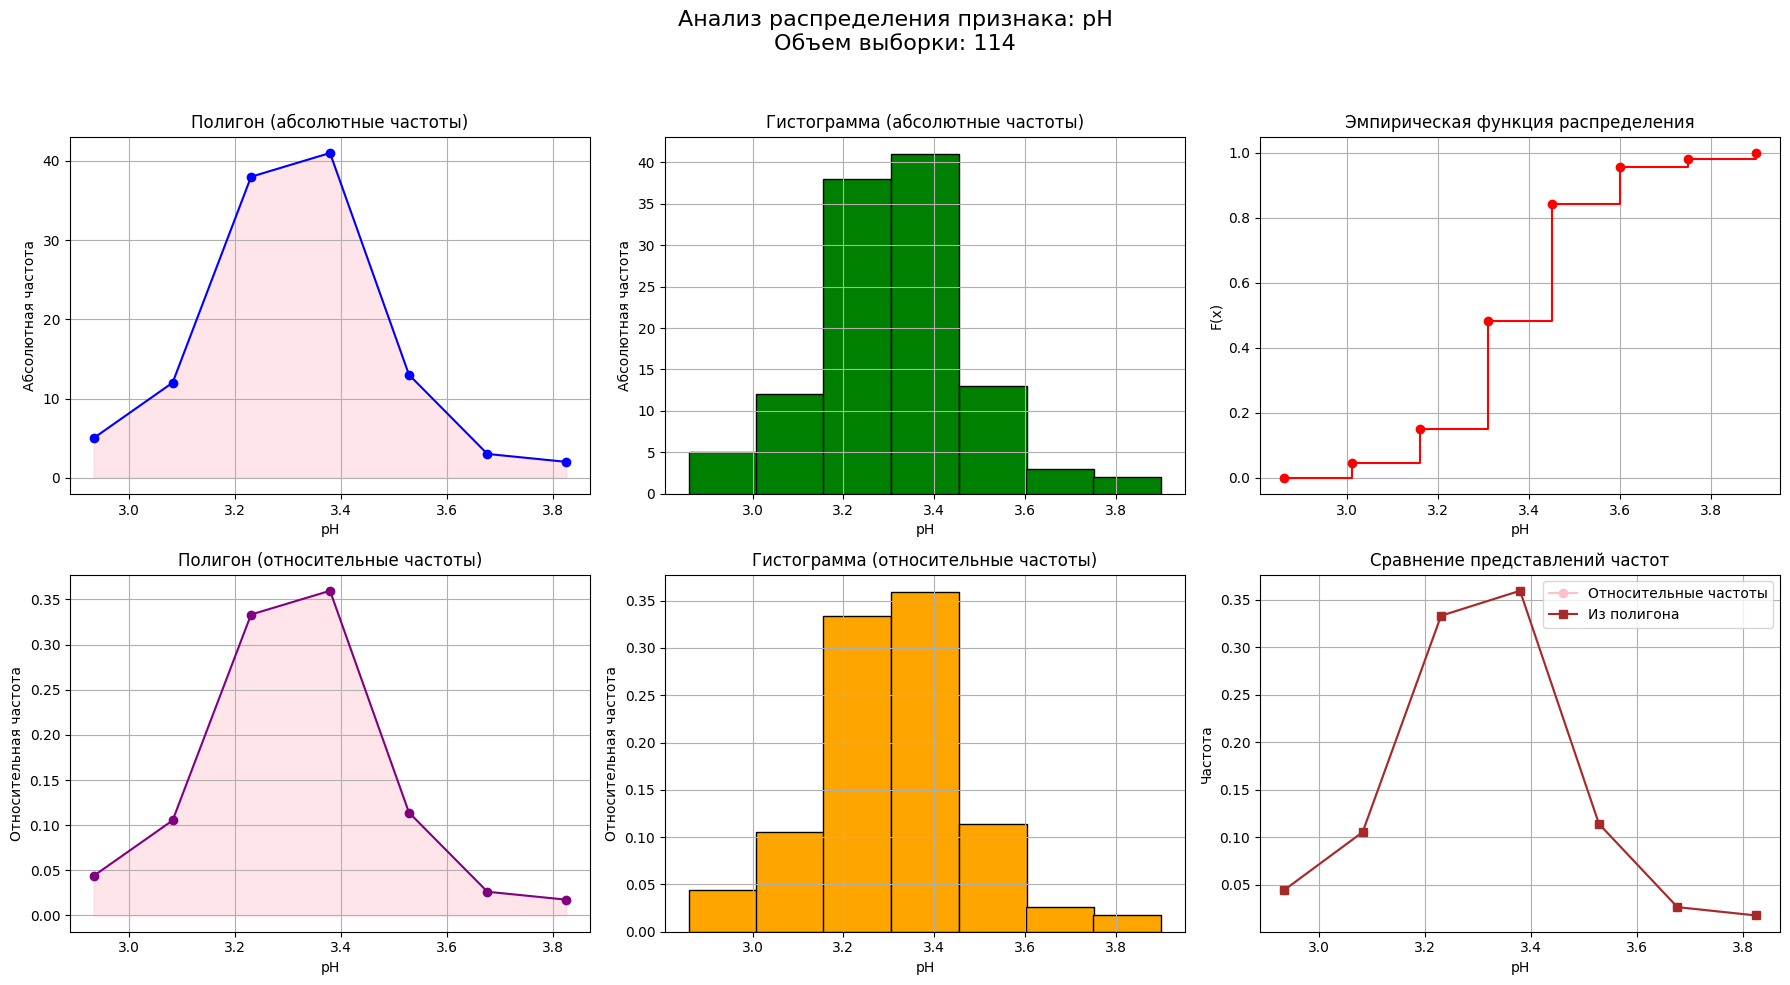

In [12]:
N = len(data_ph)
plot_analysis(table=ph_table, N=N, title="pH")

Полигон и гистограмма абсолютных частот:
- Наглядно демонстрируют распределение значений pH.
- Пик распределения приходится на интервал [3.31, 3.45) с частотой 41 наблюдение.
- Форма распределения асимметричная, с более пологим левым склоном.
- Наблюдается убывание частот к краям распределения.

Эмпирическая функция распределения:
- Позволяет определить вероятность попадания значения в заданный интервал.
- Медианное значение соответствует F(x) = 0.5 (около 3.31).

Сравнение графиков для абсолютных и относительных частот:
- Форма распределения идентична, различие только в масштабе оси ординат.
- Относительные частоты удобнее для сравнения распределений разных выборок.
- Оба представления подтверждают левостороннюю асимметрию распределения.


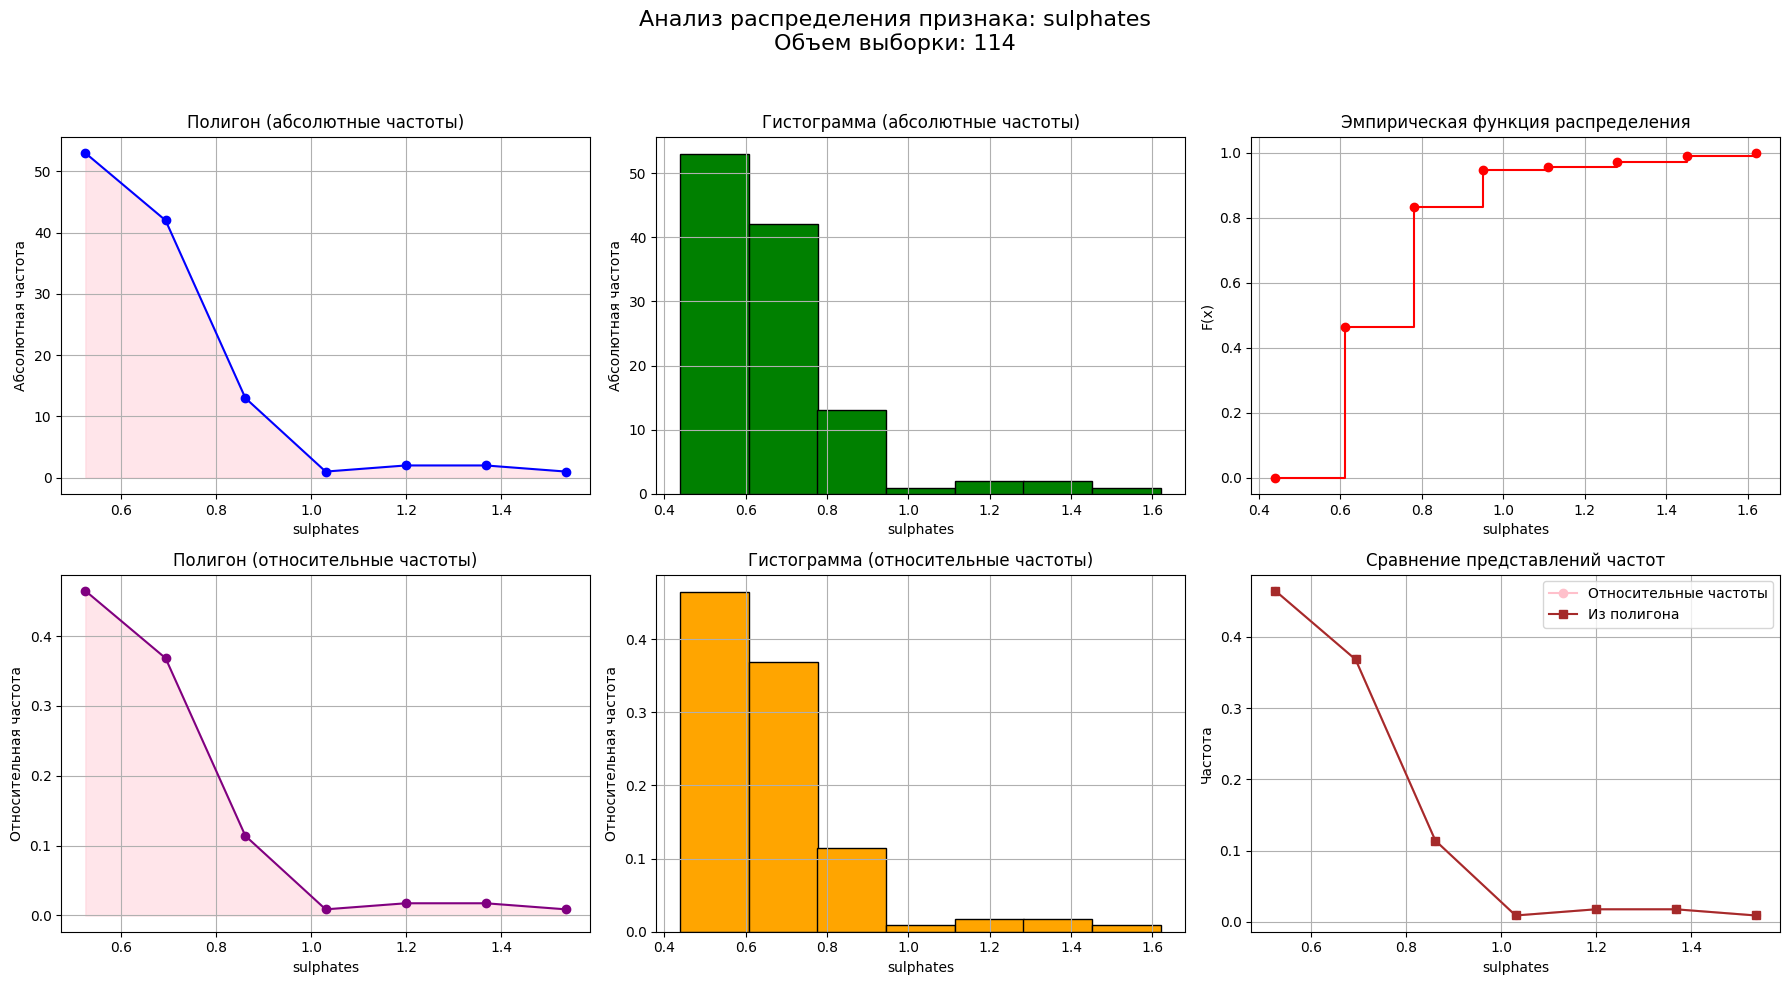

In [13]:
N = len(data_sulphates)
plot_analysis(table=sulphates_table, N=N, title="sulphates")

Полигон и гистограмма абсолютных частот:
- Ярко выраженная правосторонняя асимметрия (среднее > медианы).
- Основная масса наблюдений (около 46.5%) сосредоточена в первом интервале [0.44, 0.61).
- Наблюдается резкое убывание частот после 0.61.
- Присутствуют редкие наблюдения с высокими значениями (до 1.62) - "длинный хвост".

2. Эмпирическая функция распределения F(x):
- Быстрый рост в области низких значений (0.44-0.61).
- Более пологий рост при высоких значениях.
- Медианное значение (0.62) находится в начале второго интервала.

3. Сравнение графиков для абсолютных и относительных частот:
- Оба представления демонстрируют одинаковую форму распределения.


Оба представления необходимы для полного анализа. Абсолютные частоты дают конкретное наполнение выборки, а относительные позволяют абстрагироваться от объема выборки и сосредоточиться на форме распределения.

### **Выводы**
В ходе выполнения работы были освоены основные правила формирования выборки из генеральной совокупности: на первом этапе методом простого случайного отбора с фиксированным значением random_state=42 сформирована репрезентативная выборка объемом 114 наблюдений, после чего выполнена ее подготовка к статистическому анализу путем построения ранжированного, вариационного и интервального рядов для признаков pH и sulphates. Интервальный ряд, построенный с использованием формулы Стерджесса для определения оптимального числа интервалов (k=7), позволил сгруппировать данные и выявить основные закономерности распределения: для pH наиболее типичным является интервал [3.31, 3.45) с частотой 41 наблюдение (36% выборки), среднее значение составило 3.308 при медиане 3.310, что указывает на незначительную левостороннюю асимметрию; для sulphates модальный интервал [0.44, 0.61) содержит 53 наблюдения (46.5% выборки), среднее значение 0.660, медиана 0.620, коэффициент вариации 28.4% свидетельствует об однородности совокупности. Графический анализ (полигоны, гистограммы и эмпирические функции распределения для абсолютных и относительных частот) наглядно подтвердил выявленные закономерности: левостороннюю асимметрию для pH и правостороннюю с длинным "хвостом" для sulphates, при этом сопоставление абсолютных и относительных частот показало идентичность формы распределений, различающихся лишь масштабом, что позволяет использовать относительные частоты для сравнения с другими выборками и вероятностной интерпретации результатов. Таким образом, поставленная цель достигнута: освоены методы формирования выборки и ее подготовки к статистическому анализу.